# Training a PPO racing agent

This notebook uses the project-owned `PPOAgent` and the readable `PPOTrainingEngine`. The equations and boundary rules follow [`docs/LEARNING.md`](../docs/LEARNING.md); the shared experiment engine is not used.

## PPO, GAE, and clipped policy updates

PPO retains A2C's critic and detached GAE targets, but reuses each fixed rollout for several seeded minibatch epochs. The importance ratio compares the current policy with the behaviour policy that collected each action. The actor minimizes the clipped surrogate from `docs/LEARNING.md`; the critic still minimizes the unclipped half-squared error to its fixed target. Approximate KL and clip fraction are diagnostics rather than stopping rules in this project.

## Configuration

The retained execution uses four episodes only as a smoke test. Increase `TRAINING_EPISODES` for a learning experiment. The explicit learning-rate pair is a documented candidate and remains an educational placeholder until calibration. Scheduled evaluation uses deterministic bounded mean actions and frozen normalization.

In [1]:
import sys
import time
from dataclasses import asdict, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from agents import PPOAgent
from configs import (
    FIXED_CRITIC_CONFIG,
    MEDIUM_ACTOR_CONFIG,
    EnvironmentConfig,
    ExecutionConfig,
    ObservationNormalizationConfig,
    PPOConfig,
)
from envs.racing import RacingEnv
from envs.tracks import TrackWithGeometry
from recording import RunCategory
from training.engines.ppo import PPOTrainingEngine
from training.evaluation import evaluate_deterministic
from training.normalization import RunningObservationNormalizer
from utils.random import (
    RunSeedStreams,
    SeedNamespace,
    SeedStream,
    configure_torch_determinism,
)

ROOT_SEED = 0
DEVICE = "cpu"
TRAINING_EPISODES = 4  # Smoke setting; increase for a learning run.

TRAIN_ON_MULTIPLE_CIRCUITS = False
SINGLE_CIRCUIT_SEED = 0
MULTIPLE_CIRCUIT_SEEDS = (0, 1, 2)
EVALUATION_CIRCUIT_INDEX = 0

ACTOR_CONFIG = replace(MEDIUM_ACTOR_CONFIG, learning_rate=3e-4)
CRITIC_LEARNING_RATE = 1e-3
PPO_CONFIG = PPOConfig(
    discount=0.9995,
    gae_lambda=0.95,
    transitions_per_rollout=2_048,
    optimization_epochs=10,
    minibatch_size=64,
    clip_epsilon=0.2,
)
ENVIRONMENT_CONFIG = EnvironmentConfig()
NORMALIZATION_CONFIG = ObservationNormalizationConfig()

EVALUATION_INTERVAL_EPISODES = 2  # Educational placeholder.
EVALUATION_EPISODES = 1
MOVING_AVERAGE_WINDOW = 20

RENDER_CIRCUIT_INDEX = 0
RENDER_RESET_SEED = 123
VIEWER_MODE = "inline"  # "inline" or "window"
LIVE_RENDER_MAX_STEPS = 300
LIVE_FRAME_DELAY = 0.01

C:\Users\Filippo Corti\Documents\GitHub\ReinforcementLearning\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## Build circuits, random streams, agent, and engine

PPO has one additional independent stream for minibatch order. This keeps optimization order separate from actor sampling, environment resets, circuit selection, and deterministic evaluation.

In [2]:
execution_config = ExecutionConfig(device=DEVICE)
configure_torch_determinism(execution_config)
streams = RunSeedStreams(SeedNamespace.MULTI_CIRCUIT_DEVELOPMENT, ROOT_SEED)

circuit_seeds = (
    MULTIPLE_CIRCUIT_SEEDS if TRAIN_ON_MULTIPLE_CIRCUITS else (SINGLE_CIRCUIT_SEED,)
)
tracks = tuple(
    TrackWithGeometry.generate(
        seed,
        track_config=ENVIRONMENT_CONFIG.track,
        vehicle_config=ENVIRONMENT_CONFIG.vehicle,
    )
    for seed in circuit_seeds
)
probe_environment = RacingEnv(tracks[0], config=ENVIRONMENT_CONFIG)
observation_dimensions = probe_environment.observation_space.shape[0]
probe_environment.close()

agent = PPOAgent(
    observation_dimensions=observation_dimensions,
    actor_config=ACTOR_CONFIG,
    critic_config=FIXED_CRITIC_CONFIG,
    config=PPO_CONFIG,
    critic_learning_rate=CRITIC_LEARNING_RATE,
    actor_initialization_generator=streams.get_torch_generator(
        SeedStream.ACTOR_INITIALIZATION, device=DEVICE
    ),
    critic_initialization_generator=streams.get_torch_generator(
        SeedStream.CRITIC_INITIALIZATION, device=DEVICE
    ),
    sampling_generator=streams.get_torch_generator(
        SeedStream.POLICY_ACTION_SAMPLING, device=DEVICE
    ),
    optimization_generator=streams.get_torch_generator(
        SeedStream.OPTIMIZATION_BATCH_ORDER, device=DEVICE
    ),
    device=DEVICE,
)
normalizer = RunningObservationNormalizer(observation_dimensions, NORMALIZATION_CONFIG)
engine = PPOTrainingEngine(
    agent=agent,
    tracks=tracks,
    environment_config=ENVIRONMENT_CONFIG,
    normalizer=normalizer,
    environment_reset_generator=streams.get_numpy_generator(
        SeedStream.ENVIRONMENT_RESETS
    ),
    track_selection_generator=streams.get_numpy_generator(
        SeedStream.TRAINING_TRACK_SELECTION
    ),
)
evaluation_generator = streams.get_numpy_generator(SeedStream.EVALUATION)

print(f"Circuits used for training: {circuit_seeds}")
print(f"Actor parameters: {agent.actor_parameter_count:,}")
print(f"Critic parameters: {agent.critic_parameter_count:,}")

Circuits used for training: (0,)
Actor parameters: 4,612
Critic parameters: 4,545


## Watch the policy before training

The live viewer applies deterministic bounded mean actions and frozen normalization, so it does not consume PPO's policy-sampling stream. Inline mode updates one notebook figure after every environment step. Set `VIEWER_MODE = "window"` for the local Pygame display if the notebook frontend does not animate updates.

In [3]:
def watch_rendered_rollout(title, track):
    if VIEWER_MODE not in {"inline", "window"}:
        raise ValueError("VIEWER_MODE must be 'inline' or 'window'.")

    render_mode = "rgb_array" if VIEWER_MODE == "inline" else "human"
    environment = RacingEnv(track, config=ENVIRONMENT_CONFIG, render_mode=render_mode)
    observation, info = environment.reset(seed=RENDER_RESET_SEED)
    total_return = 0.0
    figure = None

    if VIEWER_MODE == "inline":
        figure, axis = plt.subplots(figsize=(7, 7))
        image = axis.imshow(environment.render())
        axis.axis("off")
        display_handle = display(figure, display_id=True)
    else:
        environment.render()

    try:
        for step in range(1, LIVE_RENDER_MAX_STEPS + 1):
            normalized_observation = normalizer.normalize(observation)
            action = agent.deterministic_action(normalized_observation)
            observation, reward, terminated, truncated, info = environment.step(action)
            total_return += float(reward)
            if VIEWER_MODE == "inline":
                image.set_data(environment.render())
                axis.set_title(f"{title} | step {step} | return {total_return:.2f}")
                display_handle.update(figure)
            else:
                environment.render()
            time.sleep(LIVE_FRAME_DELAY)
            if terminated or truncated:
                break
    finally:
        environment.close()
        if figure is not None:
            plt.close(figure)

    return {
        "interactions": step,
        "return": total_return,
        "collision": bool(info["collision"]),
        "lap_completed": bool(info["lap_completed"]),
        "progress": float(info["episode_progress"]) / track.track.track_length,
    }

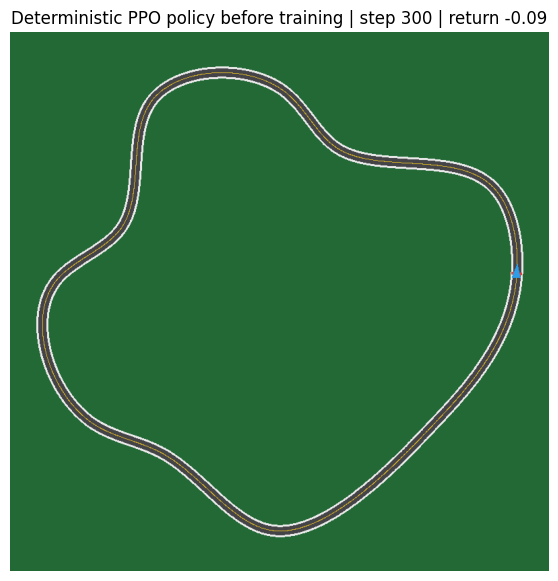

{'interactions': 300,
 'return': -0.08892291780115615,
 'collision': False,
 'lap_completed': False,
 'progress': 0.0010770821988438611}

In [4]:
initial_rollout = watch_rendered_rollout(
    "Deterministic PPO policy before training", tracks[RENDER_CIRCUIT_INDEX]
)
initial_rollout

## Scheduled deterministic evaluation

The episode callback observes training without ending PPO's current fixed rollout. Evaluation uses a fresh environment, deterministic mean actions, frozen normalization statistics, and its own reset seeds. An evaluation before training provides the baseline point.

In [5]:
evaluation_rows = []
evaluation_state = {"interactions": 0}
evaluation_track = tracks[EVALUATION_CIRCUIT_INDEX]


def run_greedy_evaluation(completed_training_episodes, training_interactions):
    for _ in range(EVALUATION_EPISODES):
        result = evaluate_deterministic(
            lambda: RacingEnv(evaluation_track, config=ENVIRONMENT_CONFIG),
            agent,
            normalizer,
            run_category=RunCategory.REDUCED_VALIDATION,
            evaluation_index=len(evaluation_rows),
            training_interactions=training_interactions,
            evaluation_interactions_before=evaluation_state["interactions"],
            reset_seed=int(evaluation_generator.integers(0, 2**32, dtype=np.uint32)),
            root_identity=ROOT_SEED,
            circuit_identity=str(evaluation_track.track.generation.seed),
        )
        episode = result.record.episode
        evaluation_state["interactions"] = result.record.evaluation_interactions
        evaluation_rows.append(
            {
                "evaluation_index": result.record.evaluation_index,
                "completed_training_episodes": completed_training_episodes,
                "training_interactions": training_interactions,
                "return": episode.undiscounted_return,
                "outcome": episode.outcome.value,
                "maximum_progress": episode.maximum_progress,
                "mean_speed": episode.speed.mean,
            }
        )


def evaluate_on_schedule(episode_record, current_history):
    completed_episodes = episode_record.episode_index + 1
    if completed_episodes % EVALUATION_INTERVAL_EPISODES == 0:
        run_greedy_evaluation(completed_episodes, current_history.training_interactions)


run_greedy_evaluation(0, 0)
evaluation_rows[-1]

{'evaluation_index': 0,
 'completed_training_episodes': 0,
 'training_interactions': 0,
 'return': -20.360232284747593,
 'outcome': 'crashed',
 'maximum_progress': 0.02770202862083305,
 'mean_speed': 0.9283222692209466}

## Train

The engine collects fixed behaviour-policy log probabilities and critic values. At each rollout boundary, PPO fixes its GAE advantages and value targets, then performs every configured seeded minibatch epoch.

In [6]:
history = engine.train(
    TRAINING_EPISODES,
    on_episode_end=evaluate_on_schedule,
)

print(f"Episodes collected: {len(history.episodes)}")
print(f"Training interactions: {history.training_interactions}")
print(f"Optimizer updates: {len(history.updates)}")
print(f"Greedy evaluations: {len(evaluation_rows)}")

Training episodes:   0%|          | 0/4 [00:00<?, ?episode/s]

Episodes collected: 4
Training interactions: 2353
Optimizer updates: 2
Greedy evaluations: 3


## Inspect training and evaluation records

The return graph retains every episode and overlays a trailing moving average with $w=20$; before episode 20 it averages the available prefix. Actor and critic weight norms are shown once per optimizer update because weights remain unchanged during intervening environment steps.

In [7]:
episode_rows = []
for record in history.episodes:
    row = asdict(record)
    row["outcome"] = record.outcome.value
    episode_rows.append(row)
update_rows = [asdict(record) for record in history.updates]

print("Last training episode:")
print(episode_rows[-1])
print("\nGreedy evaluation records:")
for row in evaluation_rows:
    print(row)

Last training episode:
{'episode_index': 3, 'circuit_identity': '0', 'interactions': 542, 'undiscounted_return': -20.106483776088435, 'outcome': 'crashed', 'final_progress': 0.055889776446704315, 'maximum_progress': 0.055889776446704315, 'mean_speed': None, 'mean_throttle_magnitude': None}

Greedy evaluation records:
{'evaluation_index': 0, 'completed_training_episodes': 0, 'training_interactions': 0, 'return': -20.360232284747593, 'outcome': 'crashed', 'maximum_progress': 0.02770202862083305, 'mean_speed': 0.9283222692209466}
{'evaluation_index': 1, 'completed_training_episodes': 2, 'training_interactions': 1222, 'return': -20.806809917651105, 'outcome': 'crashed', 'maximum_progress': 0.027817889821519417, 'mean_speed': 0.4334484113619188}
{'evaluation_index': 2, 'completed_training_episodes': 4, 'training_interactions': 2353, 'return': -20.118036539128642, 'outcome': 'crashed', 'maximum_progress': 0.03262782374306575, 'mean_speed': 2.8050023556185173}


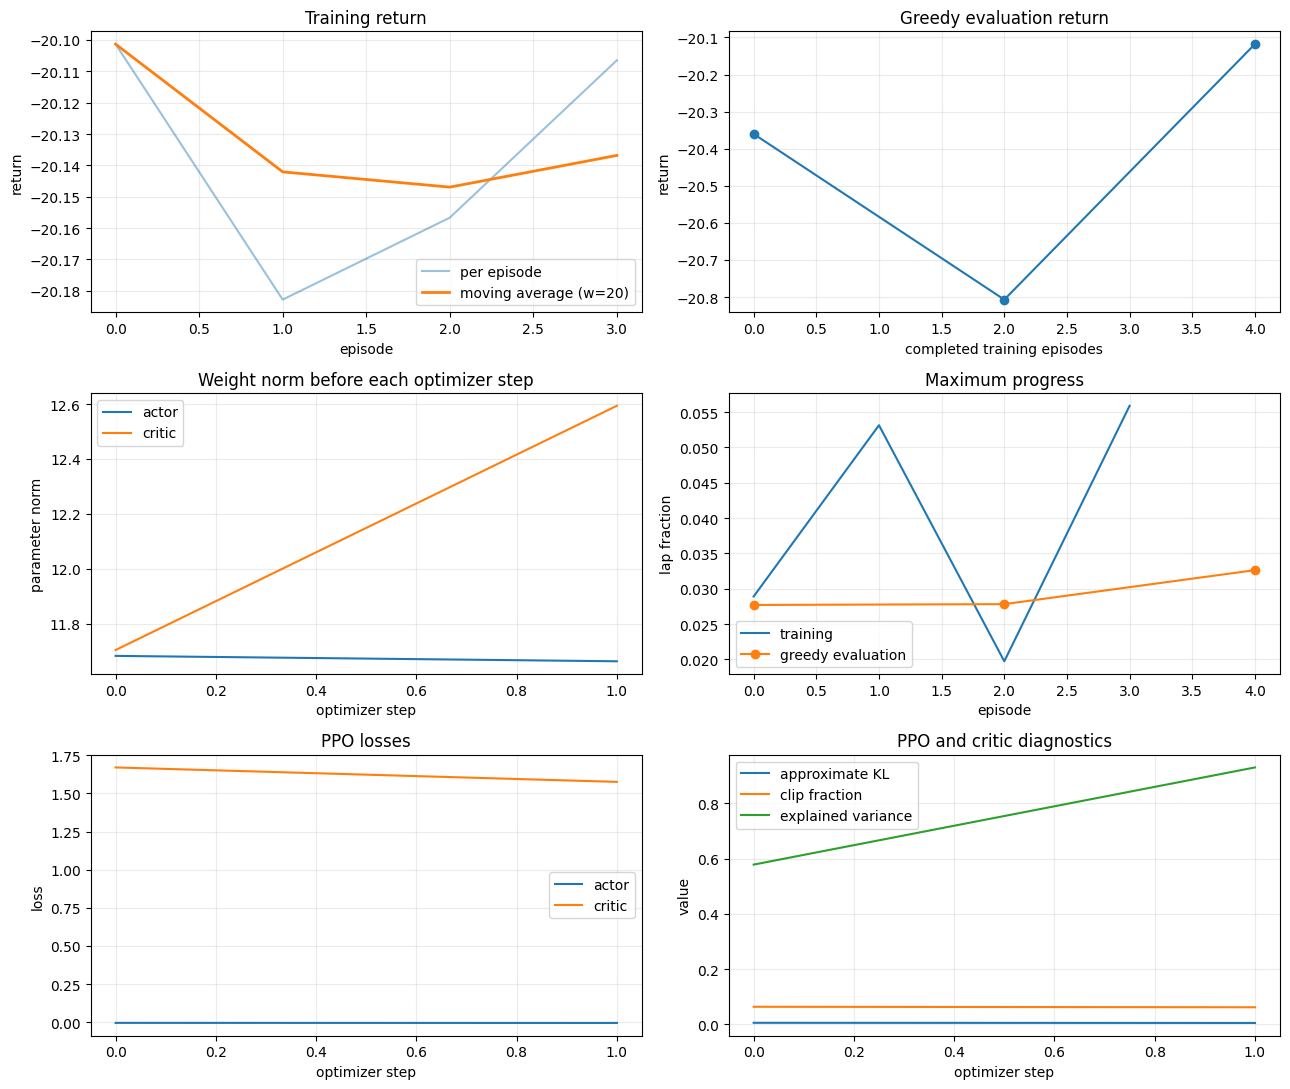

In [8]:
episode_indices = np.asarray([row["episode_index"] for row in episode_rows])
returns = np.asarray([row["undiscounted_return"] for row in episode_rows])
moving_returns = np.asarray(
    [
        np.mean(returns[max(0, index - MOVING_AVERAGE_WINDOW + 1) : index + 1])
        for index in range(len(returns))
    ]
)
update_indices = np.asarray([row["update_index"] for row in update_rows])
evaluation_episodes = np.asarray(
    [row["completed_training_episodes"] for row in evaluation_rows]
)

figure, axes = plt.subplots(3, 2, figsize=(13, 11))
axes[0, 0].plot(episode_indices, returns, alpha=0.45, label="per episode")
axes[0, 0].plot(
    episode_indices, moving_returns, linewidth=2, label="moving average (w=20)"
)
axes[0, 0].set(title="Training return", xlabel="episode", ylabel="return")
axes[0, 0].legend()
axes[0, 1].plot(
    evaluation_episodes, [row["return"] for row in evaluation_rows], marker="o"
)
axes[0, 1].set(
    title="Greedy evaluation return",
    xlabel="completed training episodes",
    ylabel="return",
)
axes[1, 0].plot(
    update_indices,
    [row["diagnostics"]["actor_weight_norm"] for row in update_rows],
    label="actor",
)
axes[1, 0].plot(
    update_indices,
    [row["diagnostics"]["critic_weight_norm"] for row in update_rows],
    label="critic",
)
axes[1, 0].set(
    title="Weight norm before each optimizer step",
    xlabel="optimizer step",
    ylabel="parameter norm",
)
axes[1, 0].legend()
axes[1, 1].plot(
    episode_indices, [row["maximum_progress"] for row in episode_rows], label="training"
)
axes[1, 1].plot(
    evaluation_episodes,
    [row["maximum_progress"] for row in evaluation_rows],
    marker="o",
    label="greedy evaluation",
)
axes[1, 1].set(title="Maximum progress", xlabel="episode", ylabel="lap fraction")
axes[1, 1].legend()
axes[2, 0].plot(
    update_indices,
    [row["diagnostics"]["actor_loss"] for row in update_rows],
    label="actor",
)
axes[2, 0].plot(
    update_indices,
    [row["diagnostics"]["critic_loss"] for row in update_rows],
    label="critic",
)
axes[2, 0].set(title="PPO losses", xlabel="optimizer step", ylabel="loss")
axes[2, 0].legend()
axes[2, 1].plot(
    update_indices,
    [row["diagnostics"]["approximate_kl"] for row in update_rows],
    label="approximate KL",
)
axes[2, 1].plot(
    update_indices,
    [row["diagnostics"]["clip_fraction"] for row in update_rows],
    label="clip fraction",
)
axes[2, 1].plot(
    update_indices,
    [row["diagnostics"]["explained_variance"] for row in update_rows],
    label="explained variance",
)
axes[2, 1].set(
    title="PPO and critic diagnostics", xlabel="optimizer step", ylabel="value"
)
axes[2, 1].legend()
for axis in axes.flat:
    axis.grid(alpha=0.25)
figure.tight_layout()
plt.show()

## Watch the policy after training

The final live rollout reuses the initial circuit, reset seed, deterministic action rule, and viewer settings for a direct visual comparison.

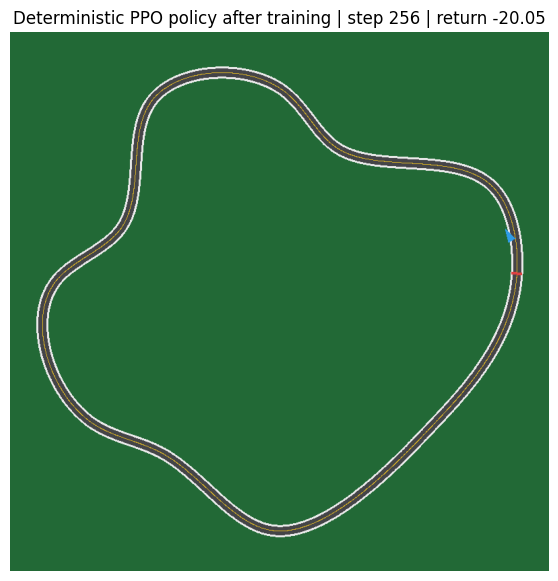

Before training: {'interactions': 300, 'return': -0.08892291780115615, 'collision': False, 'lap_completed': False, 'progress': 0.0010770821988438611}
After training:  {'interactions': 256, 'return': -20.049644396387585, 'collision': True, 'lap_completed': False, 'progress': 0.026967357192246962}


In [9]:
final_rollout = watch_rendered_rollout(
    "Deterministic PPO policy after training", tracks[RENDER_CIRCUIT_INDEX]
)
print("Before training:", initial_rollout)
print("After training: ", final_rollout)